#THIS HIV ANALYSIS DOES THE FOLLOWING:

- imports HIV surveillance data from the NYC Health Department from 2010 to 2024. The csv files were created using the Tabula application. Original NYC Health Department data were from tables in pdf files. Raw csv or excel files were not available from the NYC Health Department.  
- cleans the imported data, ensuring column names are standardized, datapoints are formatted and null data are evaluated.
- merges the individual 15 annual HIV datasets into one dataset, all_HIV.
- analyzes each annual dataset using linear regression to evaluate the relationship between the rate of new HIV diagnoses and HIV death rate. The hypothesis is that the relationship should be linear as long as adequate HIV prevention, testing and treatment are available in each United Health Fund (UHF) neighborhood, i.e. low incidence = low death rate. Outliers may indicate disparities, i.e. low incidence and high death rate may indicate inadequate treatment; high incidence and low death rate may indicate inadequate PrEP prevention but adequate treatment; low incidence and high death rate may indicate inadequate or delayed HIV testing.
- creates scatterplots of linear regression analyses.
- analyzes the merged all_HIV dataset by grouping variables : 1. rate of new HIV diagnoses by UHF neighborhood over time and 2. HIV death rate by UHF neighborhood over time. The 2024 Annual Surveillance Report published in December 2025 by the NYC Health Department cites an alarming year-over-year increase in new HIV diagnoses citywide since 2020. This trend is in contrast to a steady decline in new HIV diagnoses citywide prior to 2020. This analysis pinpoints the neighborhoods which may be driving this worrying trend.
- creates graphs of 1. Rate of new HIV diagnoses by UHF neighborhood over time and 2. HIV death rate by UHF neighborhood over time.


In [1]:
import pandas as pd

In [2]:
##IMPORT HIV DATASETS##

HIV_2010 = pd.read_csv ('../Data/2010_HIV_BY_UHF.csv')
HIV_2011 = pd.read_csv ('../Data/2011_HIV_BY_UHF.csv')
HIV_2012 = pd.read_csv ('../Data/2012_HIV_BY_UHF.csv')
HIV_2013 = pd.read_csv ('../Data/2013_HIV_BY_UHF .csv')
HIV_2014 = pd.read_csv ('../Data/2014_HIV_BY_UHF .csv')
HIV_2015 = pd.read_csv ('../Data/2015_HIV_BY_UHF .csv')
HIV_2016 = pd.read_csv ('../Data/2016_HIV_BY_UHF .csv')
HIV_2017 = pd.read_csv ('../Data/2017_HIV_BY_UHF .csv')
HIV_2018 = pd.read_csv ('../Data/2018_HIV_BY_UHF .csv')
HIV_2019 = pd.read_csv ('../Data/2019_HIV_BY_UHF .csv')
HIV_2020 = pd.read_csv ('../Data/2020_HIV_BY_UHF .csv')
HIV_2021 = pd.read_csv ('../Data/2021_HIV_BY_UHF .csv')
HIV_2022 = pd.read_csv ('../Data/2022_HIV_BY_UHF .csv')
HIV_2023 = pd.read_csv ('../Data/2023_HIV_BY_UHF .csv')
HIV_2024 = pd.read_csv ('../Data/2024_HIV_BY_UHF .csv')



In [3]:
##CHANGE COLUMNS NAMES TO UPPER CASE##

HIV_2010.columns = HIV_2010.columns.str.upper ()
HIV_2011.columns = HIV_2011.columns.str.upper ()
HIV_2012.columns = HIV_2012.columns.str.upper ()
HIV_2013.columns = HIV_2013.columns.str.upper ()
HIV_2014.columns = HIV_2014.columns.str.upper ()
HIV_2015.columns = HIV_2015.columns.str.upper ()
HIV_2016.columns = HIV_2016.columns.str.upper ()
HIV_2017.columns = HIV_2017.columns.str.upper ()
HIV_2018.columns = HIV_2018.columns.str.upper ()
HIV_2019.columns = HIV_2019.columns.str.upper ()
HIV_2020.columns = HIV_2020.columns.str.upper ()
HIV_2021.columns = HIV_2021.columns.str.upper ()
HIV_2022.columns = HIV_2022.columns.str.upper ()
HIV_2023.columns = HIV_2023.columns.str.upper ()
HIV_2024.columns = HIV_2024.columns.str.upper ()

HIV_2024.dtypes





UNNAMED: 0                                               str
YEAR                                                   int64
HIV DIAGNOSES PER 100,000 POPULATION                     str
PEOPLE WITH HIV AS PERCENT OF POPULATION             float64
AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV        str
2023 NEW YORK CITY POPULATION                            str
dtype: object

In [4]:
##MERGE DATASETS##

all_HIV = pd.concat ([HIV_2010, HIV_2011, HIV_2012, HIV_2013, HIV_2014, HIV_2015, HIV_2016, HIV_2017, HIV_2018, HIV_2019, HIV_2020, HIV_2021, HIV_2022, HIV_2023, HIV_2024])

print (len (all_HIV))

all_HIV.dtypes

720


UNNAMED: 0                                               str
YEAR                                                   int64
HIV DIAGNOSES PER 100,000 POPULATION                     str
PEOPLE WITH HIV AS PERCENT OF POPULATION             float64
AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV        str
2010 NEW YORK CITY POPULATION                            str
2011 NEW YORK CITY POPULATION                            str
2012 NEW YORK CITY POPULATION                            str
2013 NEW YORK CITY POPULATION                            str
2014 NEW YORK CITY POPULATION                            str
2015 NEW YORK CITY POPULATION                            str
2016 NEW YORK CITY POPULATION                            str
2017 NEW YORK CITY POPULATION                            str
2018 NEW YORK CITY POPULATION                            str
2019 NEW YORK CITY POPULATION                            str
2020 NEW YORK CITY POPULATION                            str
2021 NEW YORK CITY POPUL

In [5]:
##REMOVE ASTERISK FROM MERGED DATASET##

all_HIV ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= all_HIV ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
all_HIV.head (10)


,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2010 NEW YORK CITY POPULATION,2011 NEW YORK CITY POPULATION,2012 NEW YORK CITY POPULATION,2013 NEW YORK CITY POPULATION,2014 NEW YORK CITY POPULATION,2015 NEW YORK CITY POPULATION,2016 NEW YORK CITY POPULATION,2017 NEW YORK CITY POPULATION,2018 NEW YORK CITY POPULATION,2019 NEW YORK CITY POPULATION,2020 NEW YORK CITY POPULATION,2021 NEW YORK CITY POPULATION,2022 NEW YORK CITY POPULATION,2023 NEW YORK CITY POPULATION
0,TOTAL,2010,41.6,1.4,14.2,"8,252,456",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BRONX,2010,47.5,1.8,15.4,"1,384,143",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Crotona - Tremont,2010,59.2,2.4,16.5,"206,208",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fordham - Bronx Park,2010,49.9,1.8,12.5,"252,757",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,High Bridge - Morrisania,2010,58.6,2.6,19.7,"208,027",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Hunts Point - Mott Haven,2010,65.0,2.3,13.9,"136,924",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Kingsbridge - Riverdale,2010,17.6,0.7,11.1,"91,090",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Northeast Bronx,2010,38.3,1.2,16.7,"190,806",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Pelham - Throgs Neck,2010,36.9,1.4,12.3,"298,330",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BROOKLYN,2010,34.1,1.1,14.6,"2,556,584",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:

all_HIV ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= all_HIV ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
all_HIV.head (10)


,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2010 NEW YORK CITY POPULATION,2011 NEW YORK CITY POPULATION,2012 NEW YORK CITY POPULATION,2013 NEW YORK CITY POPULATION,2014 NEW YORK CITY POPULATION,2015 NEW YORK CITY POPULATION,2016 NEW YORK CITY POPULATION,2017 NEW YORK CITY POPULATION,2018 NEW YORK CITY POPULATION,2019 NEW YORK CITY POPULATION,2020 NEW YORK CITY POPULATION,2021 NEW YORK CITY POPULATION,2022 NEW YORK CITY POPULATION,2023 NEW YORK CITY POPULATION
0,TOTAL,2010,41.6,1.4,14.2,"8,252,456",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BRONX,2010,47.5,1.8,15.4,"1,384,143",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Crotona - Tremont,2010,59.2,2.4,16.5,"206,208",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fordham - Bronx Park,2010,49.9,1.8,12.5,"252,757",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,High Bridge - Morrisania,2010,58.6,2.6,19.7,"208,027",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Hunts Point - Mott Haven,2010,65.0,2.3,13.9,"136,924",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Kingsbridge - Riverdale,2010,17.6,0.7,11.1,"91,090",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Northeast Bronx,2010,38.3,1.2,16.7,"190,806",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Pelham - Throgs Neck,2010,36.9,1.4,12.3,"298,330",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,BROOKLYN,2010,34.1,1.1,14.6,"2,556,584",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
##REMOVE ASTERISK FROM MERGED DATASET##

all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION']= all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
all_HIV.tail (10)


,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2010 NEW YORK CITY POPULATION,2011 NEW YORK CITY POPULATION,2012 NEW YORK CITY POPULATION,2013 NEW YORK CITY POPULATION,2014 NEW YORK CITY POPULATION,2015 NEW YORK CITY POPULATION,2016 NEW YORK CITY POPULATION,2017 NEW YORK CITY POPULATION,2018 NEW YORK CITY POPULATION,2019 NEW YORK CITY POPULATION,2020 NEW YORK CITY POPULATION,2021 NEW YORK CITY POPULATION,2022 NEW YORK CITY POPULATION,2023 NEW YORK CITY POPULATION
38,Ridgewood - Forest Hills,2024,11.9,0.6,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"252,339"
39,Rockaway,2024,14.6,1.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"129,760"
40,Southeast Queens,2024,11.9,0.7,4.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"209,571"
41,Southwest Queens,2024,15.1,0.8,6.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"272,416"
42,West Queens,2024,29.6,1.4,3.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"445,740"
43,Staten Island,2024,7.9,0.5,13.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"490,687"
44,Port Richmond,2024,23.6,0.8,14.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"71,971"
45,South Beach - Tottenville,2024,2.0,0.2,5.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"195,623"
46,Stapleton - St. George,2024,12.5,1.0,16.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"127,982"
47,Willowbrook,2024,2.1,0.3,12.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"95,111"


In [8]:
##FIND ROWS WITH NaN VALUES##

print (all_HIV[all_HIV ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].isnull()])
print (all_HIV[all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION'].isnull()])

Empty DataFrame
Columns: [UNNAMED: 0, YEAR, HIV DIAGNOSES PER 100,000 POPULATION, PEOPLE WITH HIV AS PERCENT OF POPULATION, AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV, 2010 NEW YORK CITY POPULATION, 2011 NEW YORK CITY POPULATION, 2012 NEW YORK CITY POPULATION, 2013 NEW YORK CITY POPULATION, 2014 NEW YORK CITY POPULATION, 2015 NEW YORK CITY POPULATION, 2016 NEW YORK CITY POPULATION, 2017 NEW YORK CITY POPULATION, 2018 NEW YORK CITY POPULATION, 2019 NEW YORK CITY POPULATION, 2020 NEW YORK CITY POPULATION, 2021 NEW YORK CITY POPULATION, 2022 NEW YORK CITY POPULATION, 2023 NEW YORK CITY POPULATION]
Index: []
Empty DataFrame
Columns: [UNNAMED: 0, YEAR, HIV DIAGNOSES PER 100,000 POPULATION, PEOPLE WITH HIV AS PERCENT OF POPULATION, AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV, 2010 NEW YORK CITY POPULATION, 2011 NEW YORK CITY POPULATION, 2012 NEW YORK CITY POPULATION, 2013 NEW YORK CITY POPULATION, 2014 NEW YORK CITY POPULATION, 2015 NEW YORK CITY POPULATION, 2016 NEW YORK CITY P

In [9]:

all_HIV.dtypes


UNNAMED: 0                                               str
YEAR                                                   int64
HIV DIAGNOSES PER 100,000 POPULATION                     str
PEOPLE WITH HIV AS PERCENT OF POPULATION             float64
AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV        str
2010 NEW YORK CITY POPULATION                            str
2011 NEW YORK CITY POPULATION                            str
2012 NEW YORK CITY POPULATION                            str
2013 NEW YORK CITY POPULATION                            str
2014 NEW YORK CITY POPULATION                            str
2015 NEW YORK CITY POPULATION                            str
2016 NEW YORK CITY POPULATION                            str
2017 NEW YORK CITY POPULATION                            str
2018 NEW YORK CITY POPULATION                            str
2019 NEW YORK CITY POPULATION                            str
2020 NEW YORK CITY POPULATION                            str
2021 NEW YORK CITY POPUL

In [10]:
##CHANGE STRING TO NUMERIC##

all_HIV [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = all_HIV [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
all_HIV.dtypes

UNNAMED: 0                                               str
YEAR                                                   int64
HIV DIAGNOSES PER 100,000 POPULATION                 float64
PEOPLE WITH HIV AS PERCENT OF POPULATION             float64
AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV    float64
2010 NEW YORK CITY POPULATION                            str
2011 NEW YORK CITY POPULATION                            str
2012 NEW YORK CITY POPULATION                            str
2013 NEW YORK CITY POPULATION                            str
2014 NEW YORK CITY POPULATION                            str
2015 NEW YORK CITY POPULATION                            str
2016 NEW YORK CITY POPULATION                            str
2017 NEW YORK CITY POPULATION                            str
2018 NEW YORK CITY POPULATION                            str
2019 NEW YORK CITY POPULATION                            str
2020 NEW YORK CITY POPULATION                            str
2021 NEW YORK CITY POPUL

In [11]:
##SORT VALUES BY DEATH RATES##

all_HIV.sort_values (by="AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV", ascending= False). head (10)


,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2010 NEW YORK CITY POPULATION,2011 NEW YORK CITY POPULATION,2012 NEW YORK CITY POPULATION,2013 NEW YORK CITY POPULATION,2014 NEW YORK CITY POPULATION,2015 NEW YORK CITY POPULATION,2016 NEW YORK CITY POPULATION,2017 NEW YORK CITY POPULATION,2018 NEW YORK CITY POPULATION,2019 NEW YORK CITY POPULATION,2020 NEW YORK CITY POPULATION,2021 NEW YORK CITY POPULATION,2022 NEW YORK CITY POPULATION,2023 NEW YORK CITY POPULATION
28,Union Square - Lower East Side,2012,37.1,1.6,51.5,NaN,NaN,"201,985",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,Willowbrook,2010,3.5,0.2,43.6,"85,542",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,Willowbrook,2013,2.3,0.2,38.6,NaN,NaN,NaN,"87,176",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,Stapleton - St. George,2013,18.7,0.8,29.7,NaN,NaN,NaN,"122,947",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36,Jamaica,2012,29.6,1.0,25.2,NaN,NaN,"293,469",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,Rockaway,2020,14.4,0.9,24.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"139,344",NaN,NaN,NaN
46,Stapleton - St. George,2011,19.2,0.8,23.7,NaN,"124,679",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
47,Willowbrook,2016,12.2,0.2,23.4,NaN,NaN,NaN,NaN,NaN,NaN,"90,021",NaN,NaN,NaN,NaN,NaN,NaN,NaN
39,Rockaway,2011,22.6,0.9,23.4,NaN,"115,246",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,Coney Island - Sheepshead Bay,2010,9.3,0.4,23.3,"300,511",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
##SORT VALUES BY HIV DIAGNOSES RATE#

all_HIV.sort_values (by="HIV DIAGNOSES PER 100,000 POPULATION", ascending= True). head (10)


,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2010 NEW YORK CITY POPULATION,2011 NEW YORK CITY POPULATION,2012 NEW YORK CITY POPULATION,2013 NEW YORK CITY POPULATION,2014 NEW YORK CITY POPULATION,2015 NEW YORK CITY POPULATION,2016 NEW YORK CITY POPULATION,2017 NEW YORK CITY POPULATION,2018 NEW YORK CITY POPULATION,2019 NEW YORK CITY POPULATION,2020 NEW YORK CITY POPULATION,2021 NEW YORK CITY POPULATION,2022 NEW YORK CITY POPULATION,2023 NEW YORK CITY POPULATION
33,Bayside - Little Neck,2021,0.0,0.2,11.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"91,453",NaN,NaN
33,Bayside - Little Neck,2020,0.0,0.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"93,564",NaN,NaN,NaN
33,Bayside - Little Neck,2015,0.0,0.2,0.0,NaN,NaN,NaN,NaN,NaN,"88,470",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
45,South Beach - Tottenville,2022,1.0,0.2,2.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"196,691",NaN
33,Bayside - Little Neck,2019,1.1,0.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"92,361",NaN,NaN,NaN,NaN
33,Bayside - Little Neck,2013,1.1,0.2,8.3,NaN,NaN,NaN,"89,987",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
33,Bayside - Little Neck,2023,1.1,0.2,1.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"88,801"
33,Bayside - Little Neck,2018,1.1,0.2,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"92,610",NaN,NaN,NaN,NaN,NaN
45,South Beach - Tottenville,2024,2.0,0.2,5.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"195,623"
45,South Beach - Tottenville,2019,2.0,0.2,3.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"203,328",NaN,NaN,NaN,NaN


In [13]:
##REMOVE ASTERISKS FROM EACH HIV DATASET##

HIV_2010 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2010 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2011 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2011 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2012 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2012 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2013 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2013 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2014 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2014 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2015 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2015 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2016 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2016 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2017 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2017 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2018 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2018 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2019 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2019 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2020 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2020 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2021 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2021 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2022 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2022 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2023 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2023 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)
HIV_2024 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']= HIV_2024 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].str.replace ('*','', regex=False)

HIV_2024.head (10)


,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2023 NEW YORK CITY POPULATION
0,Total,2024,20.1,1.5,7.1,"8,258,035"
1,Bronx,2024,29.0,2.4,9.4,"1,356,476"
2,Crotona - Tremont,2024,36.5,3.2,11.7,"205,424"
3,Fordham - Bronx Park,2024,32.3,2.6,8.0,"244,924"
4,High Bridge - Morrisania,2024,41.8,3.2,9.8,"205,614"
5,Hunts Point - Mott Haven,2024,38.9,3.0,10.2,"138,738"
6,Kingsbridge - Riverdale,2024,10.2*,1.1,12.0,"87,951"
7,Northeast Bronx,2024,23.0,1.5,7.3,"195,305"
8,Pelham - Throgs Neck,2024,16.1,1.6,8.1,"285,128"
9,Brooklyn,2024,19.6,1.3,6.9,"2,561,225"


In [14]:
##REMOVE ASTERISKS FROM EACH DATASET##

HIV_2010 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2010 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2011 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2011 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2012 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2012 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2013 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2013 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2014 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2014 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2015 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2015 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2016 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2016 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2017 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2017 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2018 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2018 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2019 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2019 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2020 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2020 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2021 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2021 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2022 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2022 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2023 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2023 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)
HIV_2024 ['HIV DIAGNOSES PER 100,000 POPULATION']= HIV_2024 ['HIV DIAGNOSES PER 100,000 POPULATION'].str.replace ('*','', regex=False)

HIV_2024.head (10)



,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION",PEOPLE WITH HIV AS PERCENT OF POPULATION,"AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV",2023 NEW YORK CITY POPULATION
0,Total,2024,20.1,1.5,7.1,"8,258,035"
1,Bronx,2024,29.0,2.4,9.4,"1,356,476"
2,Crotona - Tremont,2024,36.5,3.2,11.7,"205,424"
3,Fordham - Bronx Park,2024,32.3,2.6,8.0,"244,924"
4,High Bridge - Morrisania,2024,41.8,3.2,9.8,"205,614"
5,Hunts Point - Mott Haven,2024,38.9,3.0,10.2,"138,738"
6,Kingsbridge - Riverdale,2024,10.2,1.1,12.0,"87,951"
7,Northeast Bronx,2024,23.0,1.5,7.3,"195,305"
8,Pelham - Throgs Neck,2024,16.1,1.6,8.1,"285,128"
9,Brooklyn,2024,19.6,1.3,6.9,"2,561,225"


In [15]:
##CHANGE STRING TO NUMERIC IN ALL DATASETS#

HIV_2010 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2010 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2011 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2011 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2012 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2012 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2013 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2013 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2014 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2014 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2015 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2015 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2016 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2016 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2017 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2017 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2018 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2018 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2019 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2019 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2020 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2020 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2021 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2021 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2022 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2022 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2023 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2023 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)
HIV_2024 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']] = HIV_2024 [['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV', 'HIV DIAGNOSES PER 100,000 POPULATION']].astype (float)

HIV_2024.dtypes


UNNAMED: 0                                               str
YEAR                                                   int64
HIV DIAGNOSES PER 100,000 POPULATION                 float64
PEOPLE WITH HIV AS PERCENT OF POPULATION             float64
AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV    float64
2023 NEW YORK CITY POPULATION                            str
dtype: object

In [16]:
#FIND NaN VALUES IN ALL DATASETS - CHANGE YEAR FOR EACH DATASET##

print (HIV_2010[HIV_2010 ['HIV DIAGNOSES PER 100,000 POPULATION'].isnull()])
print (HIV_2010[HIV_2010 ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].isnull()])




Empty DataFrame
Columns: [UNNAMED: 0, YEAR, HIV DIAGNOSES PER 100,000 POPULATION, PEOPLE WITH HIV AS PERCENT OF POPULATION, AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV, 2010 NEW YORK CITY POPULATION]
Index: []
Empty DataFrame
Columns: [UNNAMED: 0, YEAR, HIV DIAGNOSES PER 100,000 POPULATION, PEOPLE WITH HIV AS PERCENT OF POPULATION, AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV, 2010 NEW YORK CITY POPULATION]
Index: []


In [17]:
#INSTALL LINEAR REGRESSION MODEL#

!pip install statsmodels

import statsmodels.api as sm



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
##LINEAR REGRESSION SETUP FOR EACH DATASET - CHANGE YEAR FOR EACH DATASET##

X= HIV_2010['HIV DIAGNOSES PER 100,000 POPULATION']
y= HIV_2010['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']

#OLS#
model = sm.OLS (y,X)
results = model.fit ()

In [19]:
results.summary ()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                                OLS Regression Results                                                
======================================================================================================================
Dep. Variable:     AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV   R-squared (uncentered):                   0.467
Model:                                                           OLS   Adj. R-squared (uncentered):              0.455
Method:                                                Least Squares   F-statistic:                              41.13
Date:                                               Fri, 17 Apr 2026   Prob (F-statistic):                    6.37e-08
Time:                                                       20:19:02   Log-Likelihood:                         -181.85
No. Observations:                                                 48   AIC:                                      365.7
Df Residuals:                                                     47   BIC:                                      367.6
Df Model:                                                          1                                                  
Covariance Type:                                           nonrobust                                                  
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
HIV DIAGNOSES PER 100,000 POPULATION     0.2209      0.034      6.413      0.000       0.152       0.290
==============================================================================
Omnibus:                       16.949   Durbin-Watson:                   0.860
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               69.872
Skew:                           0.491   Prob(JB):                     6.72e-16
Kurtosis:                       8.829   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [20]:
##INSTALL SCATTER PLOT LIBRARY##

!pip install matplotlib

from matplotlib import pyplot as plt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


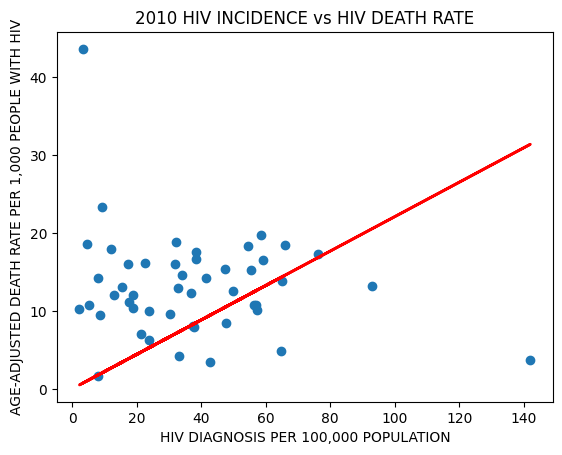

In [21]:
##CREATE THE SCATTERPLOT - MAKE SURE YOU CHANGE THE YEAR FOR THE DATAFRAME##

plt.scatter (HIV_2010 ["HIV DIAGNOSES PER 100,000 POPULATION"], HIV_2010 ["AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV"])

##CREATE THE REGRESSION LINE##
# This uses df['HIV DIAGNOSES PER 100,000 POPULATION'] for the x-axis and results.predict() for the y-axis#

plt.plot(HIV_2010 ['HIV DIAGNOSES PER 100,000 POPULATION'], 
         results.predict(), 
         color='red', 
         linewidth=2, 
         label='Regression line'
)

#CUSTOMIZE THE SCATTERPLOT#

plt.title("2010 HIV INCIDENCE vs HIV DEATH RATE")
plt.xlabel("HIV DIAGNOSIS PER 100,000 POPULATION")
plt.ylabel("AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV")
plt.savefig("../Output/2011_HIV_SCATTERPLOT.png")

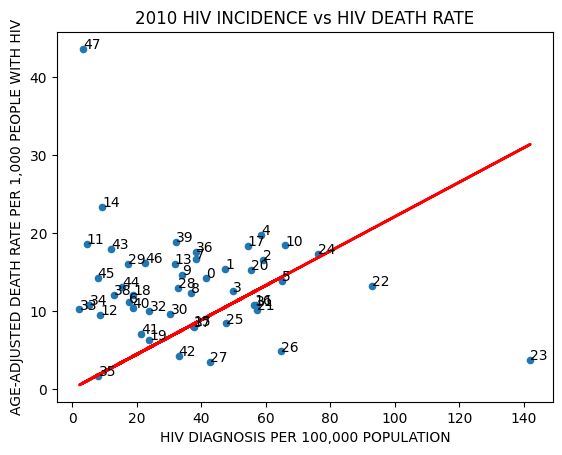

In [22]:
#LABEL POINTS ON SCATTERPLOT WITH UHF INDEX NUMBER - CHANGE YEAR ON DATAFRAME#

ax = HIV_2010.plot.scatter (
    x = 'HIV DIAGNOSES PER 100,000 POPULATION', 
    y = 'AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'
)
for i, row in HIV_2010.iterrows():
    ax.text(
        row ['HIV DIAGNOSES PER 100,000 POPULATION'], 
        row ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'], 
       str (i)
    )

plt.plot(HIV_2010 ['HIV DIAGNOSES PER 100,000 POPULATION'], 
         results.predict(), 
         color='red', 
         linewidth=2, 
         label='Regression line'
)

#CUSTOMIZE THE SCATTERPLOT - CHANGE YEAR FOR EACH DATASET#

plt.title ("2010 HIV INCIDENCE vs HIV DEATH RATE")
plt.xlabel("HIV DIAGNOSIS PER 100,000 POPULATION")
plt.ylabel("AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV")    

plt.show()



<function matplotlib.pyplot.show(close=None, block=None)>

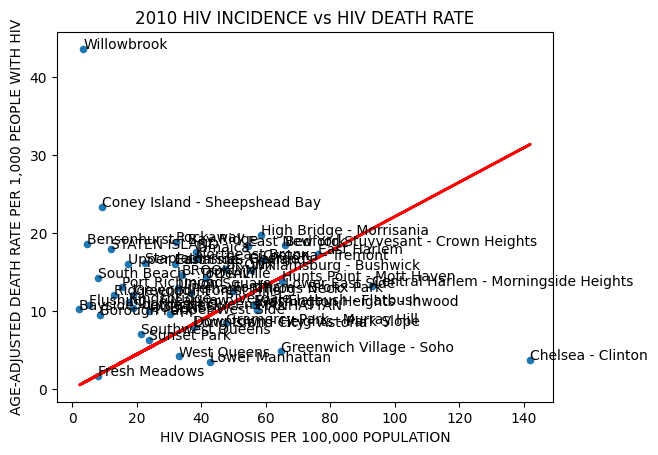

In [23]:
#LABEL POINTS ON SCATTERPLOT WITH UHF NAMES#

ax = HIV_2010.plot.scatter (
    x = 'HIV DIAGNOSES PER 100,000 POPULATION', 
    y = 'AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'
)
for i, row in HIV_2010.iterrows():
    ax.text(
        row ['HIV DIAGNOSES PER 100,000 POPULATION'], 
        row ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'], 
        row ['UNNAMED: 0']
    )

plt.plot(HIV_2010 ['HIV DIAGNOSES PER 100,000 POPULATION'], 
         results.predict(), 
         color='red', 
         linewidth=2, 
         label='Regression line'
)  

#CUSTOMIZE THE SCATTERPLOT - CHANGE YEAR FOR EACH DATASET#

plt.title ("2010 HIV INCIDENCE vs HIV DEATH RATE")
plt.xlabel("HIV DIAGNOSIS PER 100,000 POPULATION")
plt.ylabel("AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV")       

plt.show

In [24]:
##LINEAR REGRESSION SETUP FOR ALL_HIV DATASET##

X= all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION']
y= all_HIV ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']

#OLS#
model = sm.OLS (y,X)
results = model.fit ()


Text(0, 0.5, 'AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV')

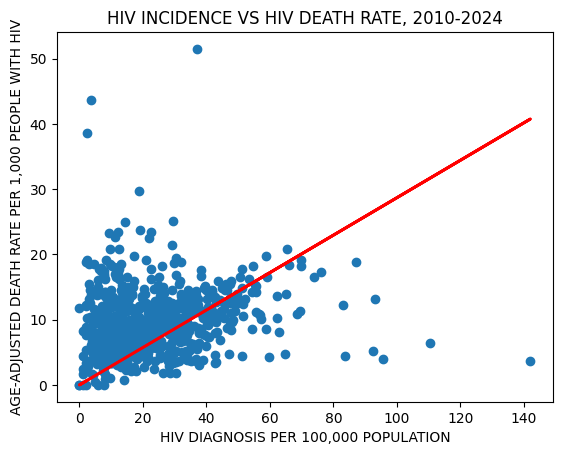

In [25]:

plt.scatter (all_HIV ["HIV DIAGNOSES PER 100,000 POPULATION"], all_HIV ["AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV"])

# create the regression line
# this uses df['HIV DIAGNOSES PER 100,000 POPULATION'] for the x-axis and results.predict() for the y-axis

plt.plot(all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION'], 
         results.predict(), 
         color='red', 
         linewidth=2, 
         label='Regression line'
)


plt.plot(all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION'], 
         results.predict(), 
         color='red', 
         linewidth=2, 
         label='Regression line'
)

# CUSTOMIZE THE SCATTERPLOT#

plt.title("HIV INCIDENCE VS HIV DEATH RATE, 2010-2024")
plt.xlabel("HIV DIAGNOSIS PER 100,000 POPULATION")
plt.ylabel("AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV")


<function matplotlib.pyplot.show(close=None, block=None)>

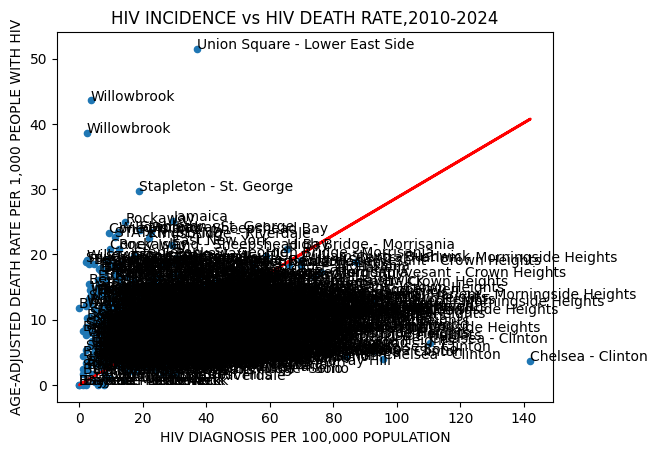

In [26]:
#ADD LABELS TO ALL_HIV DATASET SCATTERPLOT#


ax = all_HIV.plot.scatter (
    x = 'HIV DIAGNOSES PER 100,000 POPULATION', 
    y = 'AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'
)
for i, row in all_HIV.iterrows():
    ax.text(
        row ['HIV DIAGNOSES PER 100,000 POPULATION'], 
        row ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'], 
        row ['UNNAMED: 0'],
        
    )

plt.plot(all_HIV ['HIV DIAGNOSES PER 100,000 POPULATION'], 
         results.predict(), 
         color='red', 
         linewidth=2, 
         label='Regression line'
)  

#CUSTOMIZE THE SCATTERPLOT - CHANGE YEAR FOR EACH DATASET#

plt.title ("HIV INCIDENCE vs HIV DEATH RATE,2010-2024")
plt.xlabel("HIV DIAGNOSIS PER 100,000 POPULATION")
plt.ylabel("AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV")       

plt.show

In [27]:
all_HIV.dtypes

UNNAMED: 0                                               str
YEAR                                                   int64
HIV DIAGNOSES PER 100,000 POPULATION                 float64
PEOPLE WITH HIV AS PERCENT OF POPULATION             float64
AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV    float64
2010 NEW YORK CITY POPULATION                            str
2011 NEW YORK CITY POPULATION                            str
2012 NEW YORK CITY POPULATION                            str
2013 NEW YORK CITY POPULATION                            str
2014 NEW YORK CITY POPULATION                            str
2015 NEW YORK CITY POPULATION                            str
2016 NEW YORK CITY POPULATION                            str
2017 NEW YORK CITY POPULATION                            str
2018 NEW YORK CITY POPULATION                            str
2019 NEW YORK CITY POPULATION                            str
2020 NEW YORK CITY POPULATION                            str
2021 NEW YORK CITY POPUL

In [28]:
#ISOLATE COLUMNS FROM ALL_HIV MERGED DATASET#


all_HIV [['UNNAMED: 0', 'YEAR', 'HIV DIAGNOSES PER 100,000 POPULATION', 'AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV']]

,UNNAMED: 0,YEAR,"HIV DIAGNOSES PER 100,000 POPULATION","AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV"
0,TOTAL,2010,41.6,14.2
1,BRONX,2010,47.5,15.4
2,Crotona - Tremont,2010,59.2,16.5
3,Fordham - Bronx Park,2010,49.9,12.5
4,High Bridge - Morrisania,2010,58.6,19.7
...,...,...,...,...
43,Staten Island,2024,7.9,13.6
44,Port Richmond,2024,23.6,14.7
45,South Beach - Tottenville,2024,2.0,5.4
46,Stapleton - St. George,2024,12.5,16.5


In [29]:
#ESTABLISH TOP 3 UHF NEIGHBORHOODS WITH HIGHEST HIV INCIDENCE IN 2024#

latest_year = all_HIV ['YEAR'].max ()

latest = all_HIV[all_HIV['YEAR'] == latest_year]

top3 = latest.nlargest (3, 'HIV DIAGNOSES PER 100,000 POPULATION')['UNNAMED: 0']

highlight = set(top3)



In [30]:
#IMPORT LIBARY FOR GRAPHS#
import matplotlib.pyplot as plt

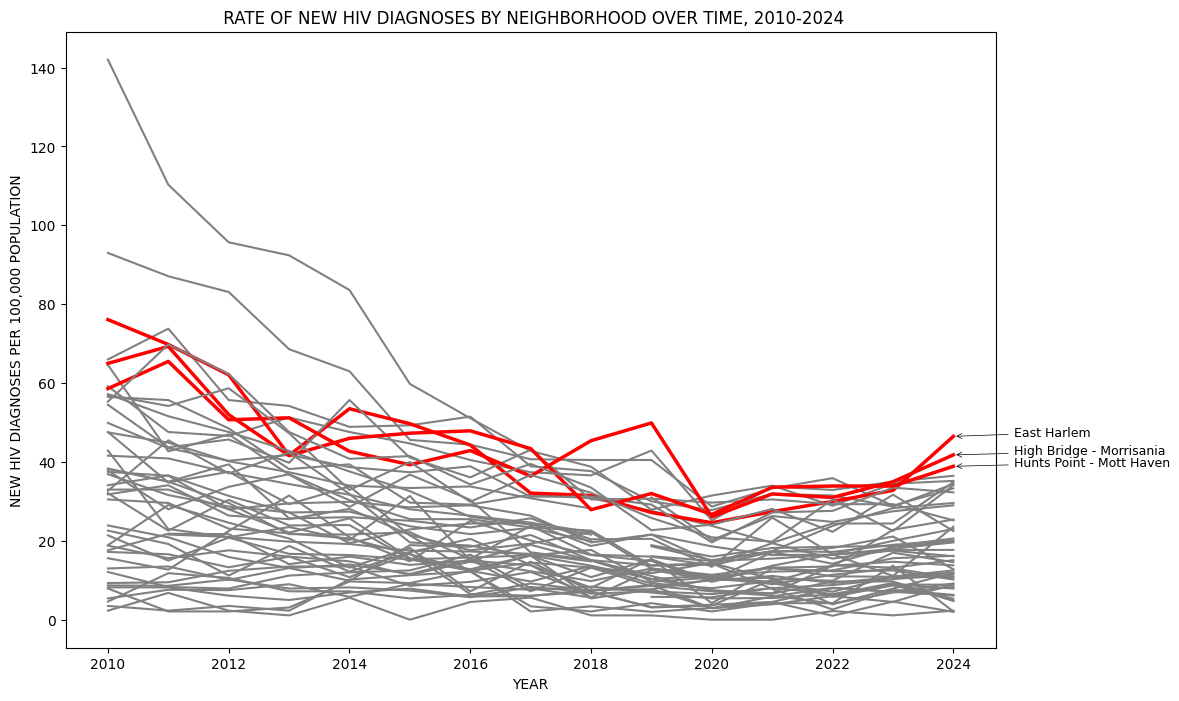

In [31]:
#CREATE GRAPH HIGHLIGHTING TOP 3 NEIGHBORHOODS WITH HIGHEST HIV INCIDENCE OVER TIME#


plt.figure (figsize=(12,8))

for neighborhood, group in all_HIV.groupby('UNNAMED: 0'):
   if neighborhood in highlight :
      if neighborhood in top3.values:
         plt.plot (group['YEAR'], group ['HIV DIAGNOSES PER 100,000 POPULATION'], color = 'red', linewidth=2.5)
      else: 
         plt.plot (group['YEAR'], group ['HIV DIAGNOSES PER 100,000 POPULATION'], color='gray', linewidth=2.5)

      #label highlighted groups#

      x= group ['YEAR'].iloc [-1]
      y= group ['HIV DIAGNOSES PER 100,000 POPULATION'].iloc [-1]

      plt.annotate (
          neighborhood,
          xy=(x,y),
          xytext=(x+1,y),
          arrowprops=dict (arrowstyle= "->", lw=0.5),
         fontsize=9
          )
   else:
         plt.plot (group ['YEAR'], group ['HIV DIAGNOSES PER 100,000 POPULATION'], color='gray', )  



plt.xlabel ('YEAR')
plt.ylabel ('NEW HIV DIAGNOSES PER 100,000 POPULATION')
plt.title (' RATE OF NEW HIV DIAGNOSES BY NEIGHBORHOOD OVER TIME, 2010-2024')

plt.show ()

In [32]:
#ESTABLISH TOP 3 NEIGHBORHOODS WITH HIGHEST HIV DEATH RATE IN 2024#

latest_year = all_HIV ['YEAR'].max ()

latest = all_HIV[all_HIV['YEAR'] == latest_year]

#top 3#
top3 = latest.nlargest (3, 'AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV')['UNNAMED: 0']

highlight = set(top3)

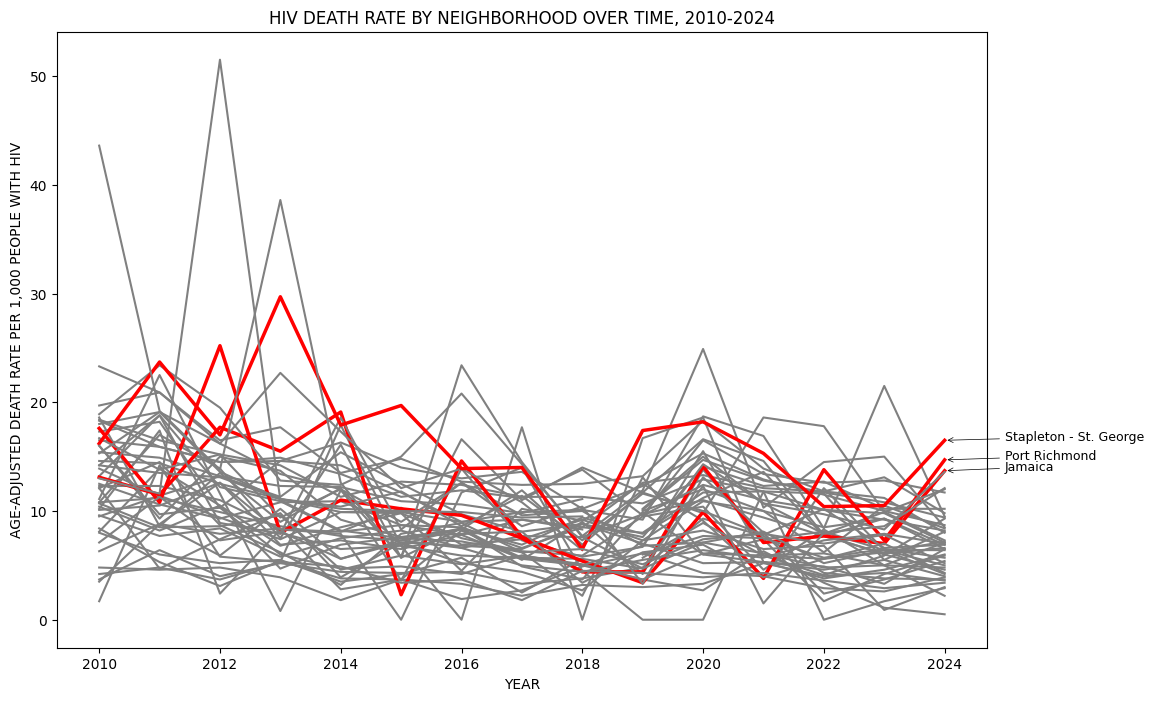

In [33]:

#CREATE GRAPH HIGHLIGHTING TOP 3 NEIGHBORHOODS WITH HIGHEST HIV DEATH RATE OVER TIME#

plt.figure (figsize=(12,8))

for neighborhood, group in all_HIV.groupby('UNNAMED: 0'):
   if neighborhood in highlight :
      if neighborhood in top3.values:
         plt.plot (group ['YEAR'], group ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'],  color = 'red', linewidth=2.5)
      else: 
         plt.plot (group ['YEAR'], group ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'], color='gray', linewidth=2.5)

      #label highlighted groups#

      x= group ['YEAR'].iloc [-1]
      y= group ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'].iloc [-1]

      plt.annotate (
          neighborhood,
          xy=(x,y),
          xytext=(x+1,y),
          arrowprops=dict (arrowstyle= "->", lw=0.5),
         fontsize=9
          )
   else:
         plt.plot (group ['YEAR'], group ['AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV'], color='gray', )  



plt.xlabel ('YEAR')
plt.ylabel ('AGE-ADJUSTED DEATH RATE PER 1,000 PEOPLE WITH HIV')
plt.title ('HIV DEATH RATE BY NEIGHBORHOOD OVER TIME, 2010-2024')

plt.show ()